# U-Net Pipeline Applied

## Set Up

In [1]:
import sys
sys.path.append('.')

import logging
import torch
from pathlib import Path

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [2]:
import train
from unet import UNet

train.dir_img = Path('./data/imgs/')
train.dir_mask = Path('./data/masks/')
train.dir_checkpoint = Path('./checkpoints/')

## Training U-Net Model

In [3]:
model = UNet(n_channels=1, n_classes=6, bilinear=False)   # set n_classes to your actual count
model = model.to(memory_format=torch.channels_last)
model = model.to(device=device)

In [5]:
train.train_model(
    model=model,
    device=device,
    epochs=1,
    batch_size=15,
    learning_rate=1e-5,
    val_percent=0.1,
    img_scale=1.0,
    amp=False,
)

INFO: Found 2 patients, 204 total slices
INFO: Scanning mask files to determine unique values (loads every volume once)...
INFO: Unique mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id 5z3o890j.


INFO: Starting training:
        Epochs:          1
        Batch size:      15
        Learning rate:   1e-05
        Training size:   94
        Validation size: 110
        Checkpoints:     True
        Device:          cpu
        Images scaling:  1.0
        Mixed Precision: False
    
c:\Users\josep\p4p\p4p\segmentation_project\Pytorch-UNet\train.py:94: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
Epoch 1/1:   0%|          | 0/94 [00:00<?, ?img/s]c:\Users\josep\p4p\p4p\segmentation_project\Pytorch-UNet\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


images shape: torch.Size([15, 1, 432, 432]) true_masks shape: torch.Size([15, 432, 432])


...

Epoch 1/1:  80%|███████▉  | 75/94 [39:28<12:15, 38.74s/img, loss (batch)=2.68]INFO: Validation Dice score: 0.1783517748117447


images shape: torch.Size([15, 1, 432, 432]) true_masks shape: torch.Size([15, 432, 432])


Epoch 1/1:  96%|█████████▌| 90/94 [1:00:53<03:38, 54.69s/img, loss (batch)=2.61]INFO: Validation Dice score: 0.1785784661769867


images shape: torch.Size([4, 1, 432, 432]) true_masks shape: torch.Size([4, 432, 432])


Epoch 1/1: 100%|██████████| 94/94 [1:23:52<00:00, 53.54s/img, loss (batch)=2.54]
INFO: Checkpoint 1 saved!


## Evaluation Final Valdiation Score

In [6]:
# reconstructing dataset and validation split (what was used internally during training)

import random
from torch.utils.data import Subset, DataLoader

from utils.data_loading import VolumeMRIDataset

# must match what you passed to train_model
img_scale = 1.0
val_percent = 0.1
batch_size = 4

dataset = VolumeMRIDataset(train.dir_img, train.dir_mask, scale=img_scale)

# mirrors the split logic inside train_model exactly
patients = list(dataset.mask_file_for.keys())
random.Random(0).shuffle(patients)
n_val_patients = max(1, int(len(patients) * val_percent))
val_patients = set(patients[:n_val_patients])

val_idx = [i for i, (p, _) in enumerate(dataset.index) if p in val_patients]
val_set = Subset(dataset, val_idx)
val_loader = DataLoader(val_set, shuffle=False, drop_last=True, batch_size=batch_size, num_workers=0, pin_memory=True)

print(f'{len(dataset.mask_file_for)} patients found: {list(dataset.mask_file_for.keys())}')
print(f'{len(dataset.mask_values)} mask values: {dataset.mask_values}')
print(f'{len(val_set)} validation slices')

INFO: Found 2 patients, 204 total slices
INFO: Scanning mask files to determine unique values (loads every volume once)...
INFO: Unique mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


2 patients found: ['CADRE_1113', 'CADRE_1598']
6 mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
110 validation slices


In [7]:
from evaluate import evaluate

val_score = evaluate(model, val_loader, device, amp=False)
print(f'Final validation Dice score: {val_score:.4f}')

Validation round:   0%|          | 0/27 [00:00<?, ?batch/s]

Final validation Dice score: 0.1848


In [8]:
# saving trained model
dir_checkpoint = train.dir_checkpoint
dir_checkpoint.mkdir(parents=True, exist_ok=True)

state_dict = model.state_dict()
state_dict['mask_values'] = dataset.mask_values
torch.save(state_dict, dir_checkpoint / 'model_final.pth')
print('Saved to', dir_checkpoint / 'model_final.pth')

Saved to checkpoints\model_final.pth


## Visualize predictions on a few validation slices

c:\Users\josep\p4p\p4p\segmentation_project\Pytorch-UNet\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


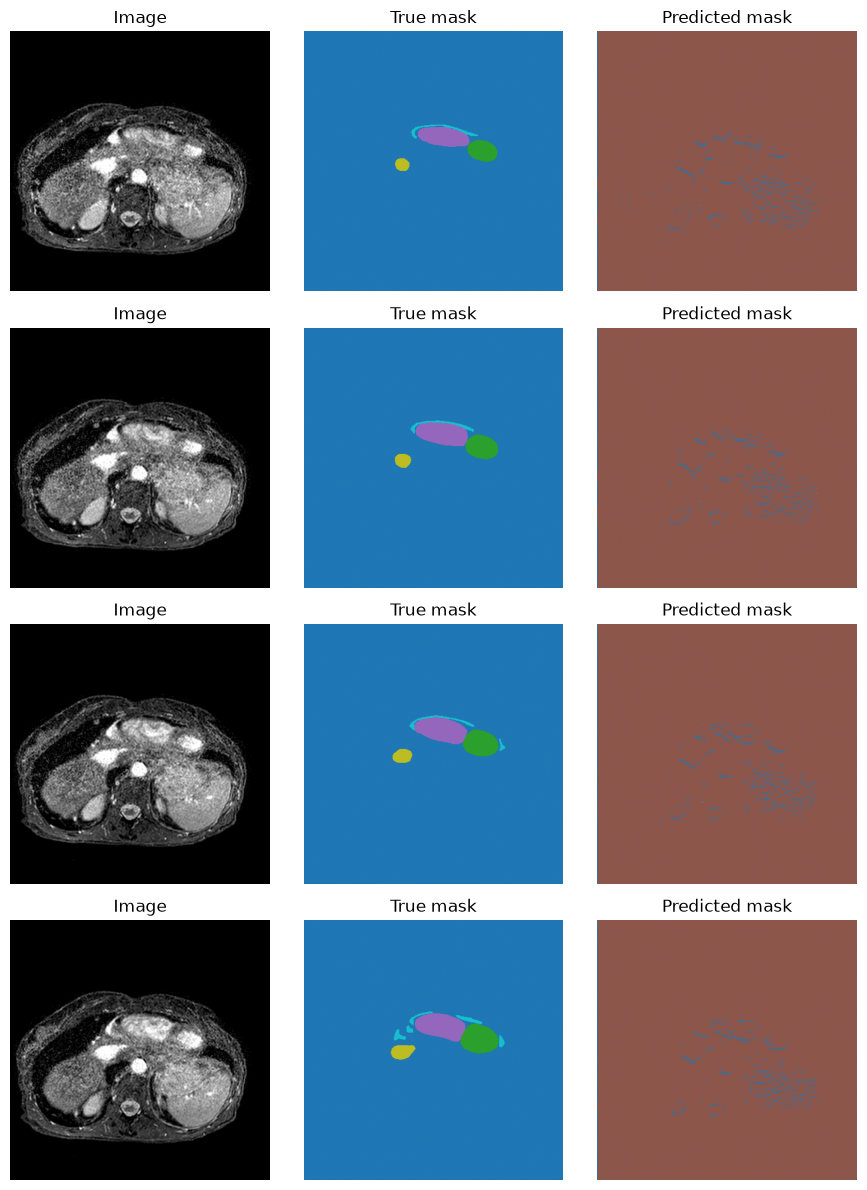

In [9]:
# USE VISLOADER for visulaisation (set drop_last to False), but use val_loader for loss
import matplotlib.pyplot as plt

model.eval()
vis_loader = DataLoader(val_set, shuffle=False, drop_last=False, batch_size=batch_size, num_workers=0, pin_memory=True)
batch = next(iter(vis_loader))
images, true_masks = batch['image'], batch['mask']

with torch.no_grad():
    images_dev = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
    preds = model(images_dev).argmax(dim=1).cpu()

# n_show = min(4, images.shape[0])
# fig, ax = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))
# for i in range(n_show):
#     ax[i, 0].imshow(images[i, 0], cmap='gray');   ax[i, 0].set_title('Image')
#     ax[i, 1].imshow(true_masks[i], cmap='tab10'); ax[i, 1].set_title('True mask')
#     ax[i, 2].imshow(preds[i], cmap='tab10');      ax[i, 2].set_title('Predicted mask')
#     for a in ax[i]: a.axis('off')
# plt.tight_layout()
# plt.show()

n_show = min(4, images.shape[0])
fig, ax = plt.subplots(n_show, 3, figsize=(9, 3 * n_show), squeeze=False)
for i in range(n_show):
    ax[i, 0].imshow(images[i, 0], cmap='gray');   ax[i, 0].set_title('Image')
    ax[i, 1].imshow(true_masks[i], cmap='tab10'); ax[i, 1].set_title('True mask')
    ax[i, 2].imshow(preds[i], cmap='tab10');      ax[i, 2].set_title('Predicted mask')
    for a in ax[i]: a.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
for i in range(n_show):
    original_idx = val_idx[i]
    patient_id, slice_idx = dataset.index[original_idx]
    print(f'Row {i}: patient = {patient_id}, slice = {slice_idx}')

Row 0: patient = CADRE_1872, slice = 0


In [ ]:
# import matplotlib.pyplot as plt

# model.eval()
# batch = next(iter(val_loader))
# images, true_masks = batch['image'], batch['mask']

# with torch.no_grad():
#     images_dev = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
#     preds = model(images_dev).argmax(dim=1).cpu()

# n_show = min(4, images.shape[0])
# fig, ax = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))
# for i in range(n_show):
#     ax[i, 0].imshow(images[i, 0], cmap='gray');   ax[i, 0].set_title('Image')
#     ax[i, 1].imshow(true_masks[i], cmap='tab10'); ax[i, 1].set_title('True mask')
#     ax[i, 2].imshow(preds[i], cmap='tab10');      ax[i, 2].set_title('Predicted mask')
#     for a in ax[i]: a.axis('off')
# plt.tight_layout()
# plt.show()

### Per-class Dice breakdown

In [10]:
from utils.dice_score import dice_coeff

model.eval()
class_scores = torch.zeros(model.n_classes)
class_counts = torch.zeros(model.n_classes)

with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
        true_masks = batch['mask'].to(device=device, dtype=torch.long)
        preds = model(images).argmax(dim=1)

        for c in range(model.n_classes):
            pred_c = (preds == c).float()
            true_c = (true_masks == c).float()
            if true_c.sum() > 0:
                class_scores[c] += dice_coeff(pred_c, true_c, reduce_batch_first=True)
                class_counts[c] += 1

for c in range(model.n_classes):
    if class_counts[c] > 0:
        print(f'Class {c}: Dice = {class_scores[c] / class_counts[c]:.4f}')
    else:
        print(f'Class {c}: never present in validation set')

Class 0: Dice = 0.0081
Class 1: Dice = 0.0000
Class 2: Dice = 0.0225
Class 3: Dice = 0.0000
Class 4: Dice = 0.0000
Class 5: Dice = 0.0000


In [17]:
print('patients:', patients)
print('val_patients:', val_patients)
print('len(dataset.index):', len(dataset.index))
print('len(val_idx):', len(val_idx))
print('len(train_idx):', len(train_idx) if 'train_idx' in dir() else 'not defined')

# manual count, bypassing the list comprehension entirely, as a cross-check
manual_count = 0
for p, s in dataset.index:
    if p in val_patients:
        manual_count += 1
print('manual count of matching entries:', manual_count)

patients: ['CADRE_1872', 'CADRE_1870', 'CADRE_1598', 'CADRE_1113', 'CADRE_1874', 'CADRE_1871', 'CADRE_1875']
val_patients: {'CADRE_1872'}
len(dataset.index): 7
len(val_idx): 1
len(train_idx): 6
manual count of matching entries: 1


In [18]:
import pydicom
ds = pydicom.dcmread(train.dir_img / 'CADRE_1872.dcm')
print(ds.pixel_array.ndim, ds.pixel_array.shape)

4 (188, 432, 432, 3)


In [14]:
dataset = VolumeMRIDataset(train.dir_img, train.dir_mask, scale=img_scale)

patients = list(dataset.mask_file_for.keys())
random.Random(0).shuffle(patients)
n_val_patients = max(1, int(len(patients) * val_percent))
val_patients = set(patients[:n_val_patients])

val_idx = [i for i, (p, _) in enumerate(dataset.index) if p in val_patients]
train_idx = [i for i, (p, _) in enumerate(dataset.index) if p not in val_patients]
val_set = Subset(dataset, val_idx)
train_set = Subset(dataset, train_idx)

print('val_patients:', val_patients)
print('val_set size:', len(val_set))

INFO: Found 7 patients, 7 total slices
INFO: Scanning mask files to determine unique values (loads every volume once)...
INFO: Unique mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


val_patients: {'CADRE_1872'}
val_set size: 1


In [8]:
import pydicom

ds = pydicom.dcmread(train.dir_img / 'CADRE_1598.dcm')
print('pixel_array shape:', ds.pixel_array.shape)
print('SamplesPerPixel:', getattr(ds, 'SamplesPerPixel', 'not set'))
print('PhotometricInterpretation:', getattr(ds, 'PhotometricInterpretation', 'not set'))

pixel_array shape: (188, 432, 432, 3)
SamplesPerPixel: 3
PhotometricInterpretation: RGB


In [10]:
import numpy as np
frame = ds.pixel_array[0]  # shape (432, 432, 3)
print(np.allclose(frame[..., 0], frame[..., 1]), np.allclose(frame[..., 1], frame[..., 2]))

True True
